已保存: e:\造数据集\midday_pairs\20190125\frame_01\20190125_midday_01_115920.jpg


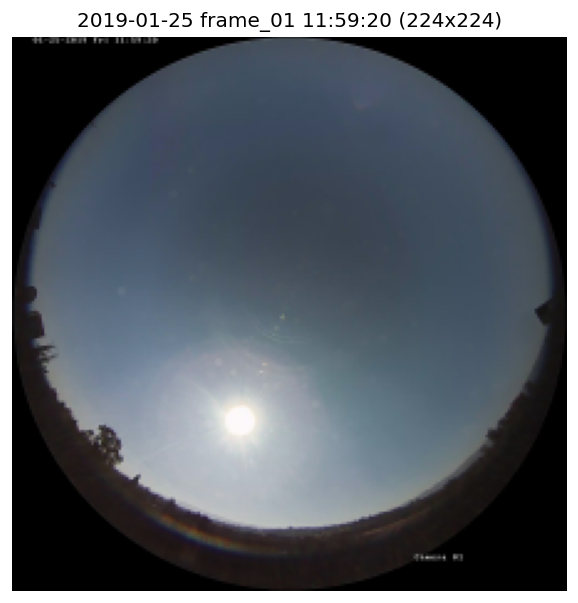

已保存: e:\造数据集\midday_pairs\20190125\frame_02\20190125_midday_02_120020.jpg


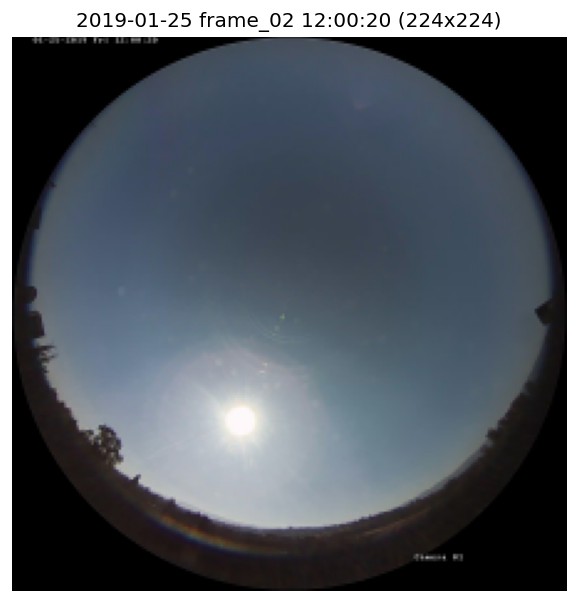

已保存: e:\造数据集\midday_pairs\20190626\frame_01\20190626_midday_01_115830.jpg


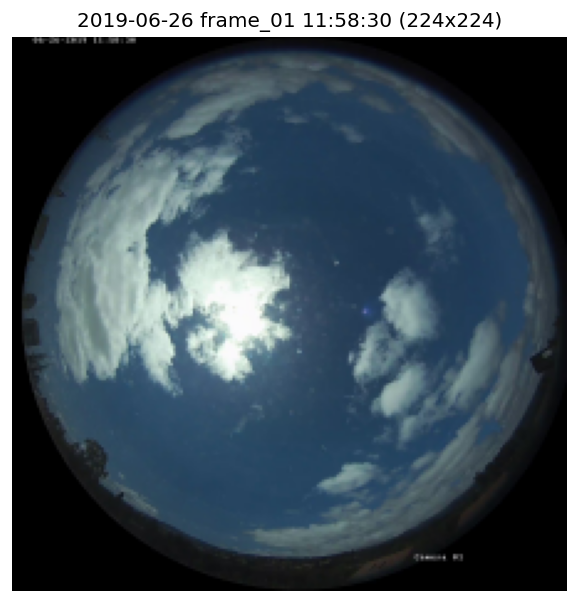

已保存: e:\造数据集\midday_pairs\20190626\frame_02\20190626_midday_02_115930.jpg


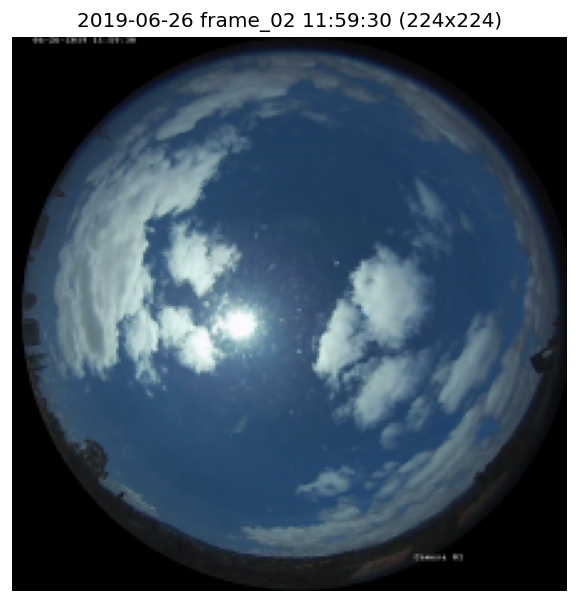

已保存: e:\造数据集\midday_pairs\20190527\frame_01\20190527_midday_01_115910.jpg


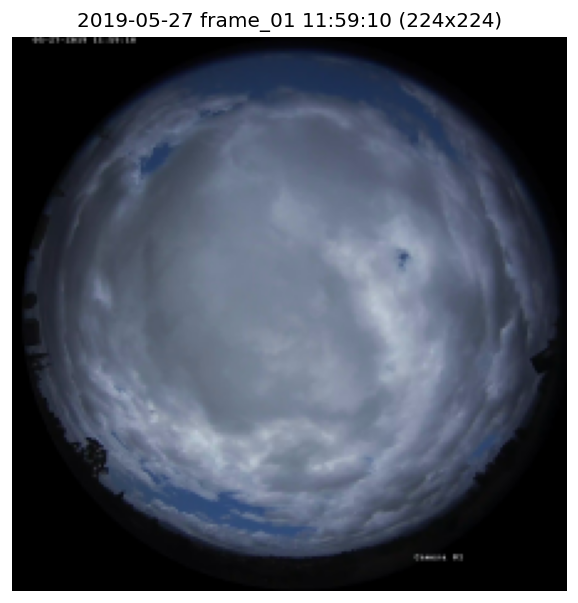

已保存: e:\造数据集\midday_pairs\20190527\frame_02\20190527_midday_02_120010.jpg


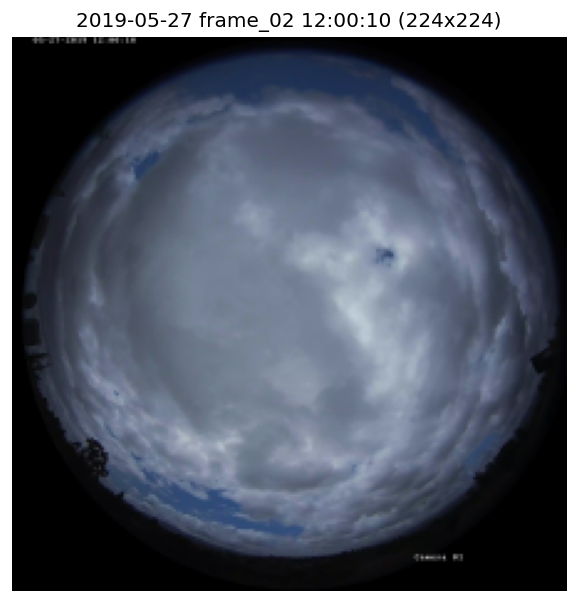

全部完成。


In [11]:
from pathlib import Path
import datetime as dt
import tarfile

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 需要提取的日期：2019 年 1 月 25 日和6月26日、 5 月 27 日
#分别晴、少云、阴
TARGET_DATES = [dt.date(2019, 1, 25), dt.date(2019,6,26), dt.date(2019, 5, 27)]
TARGET_TIME = dt.time(12, 0, 0)
TARGET_SIZE = (224,224)

BASE_DIR = Path.cwd()
TAR_DIR = BASE_DIR / "2019StanFord_image"
OUT_DIR = BASE_DIR / "midday_pairs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def parse_timestamp(member_name: str) -> dt.datetime:
    return dt.datetime.strptime(Path(member_name).stem, "%Y%m%d%H%M%S")


def load_image_from_tar(tar: tarfile.TarFile, member: tarfile.TarInfo) -> np.ndarray:
    file_obj = tar.extractfile(member)
    if file_obj is None:
        raise RuntimeError(f"无法读取文件: {member.name}")
    buffer = np.frombuffer(file_obj.read(), dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"图像解码失败: {member.name}")
    return image


def save_image_unicode(image: np.ndarray, out_file: Path) -> bool:
    ext = out_file.suffix if out_file.suffix else ".jpg"
    ok, encoded = cv2.imencode(ext, image)
    if not ok:
        return False
    encoded.tofile(str(out_file))
    return True


def find_consecutive_pair(tar_path: Path, target_date: dt.date, target_time: dt.time = TARGET_TIME):
    date_key = target_date.strftime("%Y%m%d")
    noon_dt = dt.datetime.combine(target_date, target_time)

    with tarfile.open(tar_path, "r") as tar:
        members = [
            m for m in tar.getmembers()
            if m.isfile() and m.name.endswith(".jpg") and date_key in Path(m.name).stem
        ]

        if len(members) < 2:
            raise RuntimeError(f"{tar_path.name} 中 {date_key} 的图片少于 2 张")

        members.sort(key=lambda m: Path(m.name).name)
        times = [parse_timestamp(m.name) for m in members]
        noon_idx = int(np.argmin([abs((ts - noon_dt).total_seconds()) for ts in times]))

        if noon_idx <= 0:
            pair = members[:2]
        elif noon_idx >= len(members) - 1:
            pair = members[-2:]
        else:
            pair = members[noon_idx - 1:noon_idx + 1]

        pair_times = [parse_timestamp(m.name) for m in pair]
        return pair, pair_times


for target_date in TARGET_DATES:
    month_str = f"{target_date.month:02d}"
    tar_path = TAR_DIR / f"2019_{month_str}_images_raw.tar"
    if not tar_path.exists():
        print(f"跳过 {target_date}：找不到 {tar_path.name}")
        continue

    pair_members, pair_times = find_consecutive_pair(tar_path, target_date)

    day_out_dir = OUT_DIR / target_date.strftime("%Y%m%d")
    day_out_dir.mkdir(parents=True, exist_ok=True)

    with tarfile.open(tar_path, "r") as tar:
        for idx, (member, ts) in enumerate(zip(pair_members, pair_times), start=1):
            image = load_image_from_tar(tar, member)
            image = cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_AREA)

            frame_dir = day_out_dir / f"frame_{idx:02d}"
            frame_dir.mkdir(parents=True, exist_ok=True)
            out_file = frame_dir / f"{target_date.strftime('%Y%m%d')}_midday_{idx:02d}_{ts.strftime('%H%M%S')}.jpg"
            ok = save_image_unicode(image, out_file)
            if not ok:
                print(f"写入失败: {out_file}")
            else:
                print(f"已保存: {out_file}")

            # 在 Notebook 中分别显示两帧
            plt.figure(figsize=(6, 6), dpi=120)
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title(f"{target_date} frame_{idx:02d} {ts.strftime('%H:%M:%S')} ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})")
            plt.axis("off")
            plt.show()

print("全部完成。")